# POS-Enhanced BiLSTM Named Entity Recognition (NER) - End-to-End Lifecycle
**IndoGist Machine Learning Pipeline**

This notebook documents and executes the full end-to-end lifecycle for training a dual-input Part-of-Speech (POS) enhanced Bidirectional LSTM (BiLSTM) model for Indonesian Named Entity Recognition (NER).

### Architecture & Pipeline Overview:
1. **CoNLL Data Parsing**: Extracting words, POS tags, and NER labels from CoNLL-formatted datasets (`train.txt`, `dev.txt`, `test.txt`).
2. **Dual-Input Representations**:
   - **Word Embeddings**: 150-dimensional pre-trained Word2Vec embeddings (Gensim Skip-Gram, fine-tuned during training).
   - **POS Embeddings**: 16-dimensional learned Part-of-Speech tag embeddings.
3. **BiLSTM Classifier**: Concatenation of Word + POS embeddings (166d) $\rightarrow$ 2-layer Bidirectional LSTM (64 units each, Dropout=0.2) $\rightarrow$ TimeDistributed Dense Softmax output (8 entity classes).
4. **Evaluation**: Span-level Precision, Recall, and F1-Score via `seqeval` metrics.
5. **Artifact Export & Quantization**: Full Keras model, quantized TFLite (`optimized_model.tflite`), text vectorizer, tag mappings, and configuration metadata matching the Django `NLPService` interface.

## 1. Environment Setup & Dependency Imports

In [ ]:
import os
import sys
import json
import pickle
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
from seqeval.metrics import classification_report as seq_report, f1_score as seq_f1, precision_score as seq_p, recall_score as seq_r
try:
    import keras_tuner as kt
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "keras-tuner"])
    import keras_tuner as kt

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


## 2. Custom Loss, Metrics, & seqeval Callback

In [ ]:
def masked_sparse_cce(y_true, y_pred):
    """Custom loss function that ignores padded tokens (index 0)."""
    loss_obj = keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss = loss_obj(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-12)

def masked_accuracy(y_true, y_pred):
    """Custom accuracy metric that ignores padded tokens (index 0)."""
    preds = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    matches = tf.cast(tf.equal(y_true, preds), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(matches * mask) / (tf.reduce_sum(mask) + 1e-12)

class SeqevalF1Callback(keras.callbacks.Callback):
    """Keras Callback to evaluate span-level entity F1 score at end of epoch."""
    def __init__(self, val_inputs, val_targets, idx_to_tag):
        super().__init__()
        self.val_inputs = val_inputs
        self.val_targets = val_targets
        self.idx_to_tag = idx_to_tag
        self.history_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_inputs, verbose=0)
        pred_indices = np.argmax(preds, axis=-1)
        
        true_seqs = []
        pred_seqs = []
        for i in range(len(self.val_targets)):
            t_seq = []
            p_seq = []
            for j in range(len(self.val_targets[i])):
                true_idx = self.val_targets[i][j]
                if true_idx == 0:
                    continue
                t_seq.append(self.idx_to_tag.get(true_idx, 'O'))
                p_seq.append(self.idx_to_tag.get(pred_indices[i][j], 'O'))
            true_seqs.append(t_seq)
            pred_seqs.append(p_seq)
        
        score = seq_f1(true_seqs, pred_seqs)
        self.history_f1.append(score)
        print(f" - val_entity_f1: {score:.4f}")

## 3. Dataset Loading & CoNLL Parsing

In [ ]:
def parse_conll_file(file_path):
    """Parses a CoNLL formatted dataset with format: Word POS Tag NER_Tag."""
    sentences = []
    current_sentence = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split()
                if len(parts) >= 3:
                    word, pos, tag = parts[0], parts[1], parts[2]
                    current_sentence.append((word, pos, tag))
        if current_sentence:
            sentences.append(current_sentence)
    return sentences

data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "ner"))
if not os.path.exists(data_dir):
    data_dir = r"c:\Users\GlaZ\Code_Repo\indogist\data\ner"

train_data = parse_conll_file(os.path.join(data_dir, "train.txt"))
dev_data = parse_conll_file(os.path.join(data_dir, "dev.txt"))
test_data = parse_conll_file(os.path.join(data_dir, "test.txt"))

print(f"Train dataset: {len(train_data)} sentences")
print(f"Dev dataset  : {len(dev_data)} sentences")
print(f"Test dataset : {len(test_data)} sentences")

print("\nSample Sentence (first 5 tokens):")
for tok, pos, tag in train_data[0][:5]:
    print(f"  Word: {tok:<12} POS: {pos:<8} NER: {tag}")

Train dataset: 1464 sentences
Dev dataset  : 367 sentences
Test dataset : 509 sentences

Sample Sentence (first 5 tokens):
  Word: Berikut      POS: PROPN    NER: O
  Word: adalah       POS: AUX      NER: O
  Word: tujuh        POS: NUM      NER: O
  Word: kota         POS: NOUN     NER: O
  Word: di           POS: ADP      NER: O


## 4. Vocabulary Construction & Text Vectorization

In [ ]:
def build_vocabularies(train_data, dev_data):
    """Extract unique POS tags and NER tags into index mappings."""
    pos_tags = set()
    ner_tags = set()
    for sent in train_data + dev_data:
        for _, pos, tag in sent:
            pos_tags.add(pos)
            ner_tags.add(tag)
            
    pos_to_idx = {'<PAD>': 0, '<UNK>': 1}
    for idx, pos in enumerate(sorted(pos_tags), start=2):
        pos_to_idx[pos] = idx
        
    tag_to_idx = {'<PAD>': 0}
    for idx, tag in enumerate(sorted(ner_tags), start=1):
        tag_to_idx[tag] = idx
        
    return pos_to_idx, tag_to_idx

def build_text_vectorizer(train_data, dev_data):
    """Build and adapt Keras TextVectorization layer on corpus tokens."""
    corpus_sentences = []
    for sent in train_data + dev_data:
        words = [word for word, _, _ in sent]
        corpus_sentences.append(" ".join(words))
        
    vectorizer = TextVectorization(
        standardize=None,
        split="whitespace",
        output_mode="int"
    )
    vectorizer.adapt(corpus_sentences)
    return vectorizer

pos_to_idx, tag_to_idx = build_vocabularies(train_data, dev_data)
idx_to_tag = {idx: tag for tag, idx in tag_to_idx.items()}
vectorizer = build_text_vectorizer(train_data, dev_data)
vocab = vectorizer.get_vocabulary()

print(f"Vocabulary size: {len(vocab)} words")
print(f"POS Tags count : {len(pos_to_idx)} tags ({list(pos_to_idx.keys())[:5]}...)")
print(f"NER Classes    : {len(tag_to_idx)} classes ({tag_to_idx})")

Vocabulary size: 7582 words


POS Tags count : 18 tags (['<PAD>', '<UNK>', 'ADJ', 'ADP', 'ADV']...)
NER Classes    : 8 classes ({'<PAD>': 0, 'B-LOC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-ORG': 5, 'I-PER': 6, 'O': 7})


## 5. Pretrained Word2Vec Embeddings

In [ ]:
def train_word2vec(train_data, dev_data, embed_dim=150):
    """Train Gensim Skip-Gram Word2Vec embeddings on tokenized corpus."""
    sentences = [[w for w, _, _ in sent] for sent in train_data + dev_data]
    w2v = Word2Vec(sentences, vector_size=embed_dim, window=5, min_count=1, sg=1, epochs=10, workers=4)
    return w2v

def create_embedding_matrix(vectorizer, w2v_model, embed_dim=150):
    """Align Gensim Word2Vec vectors with Keras TextVectorization vocabulary."""
    vocab = vectorizer.get_vocabulary()
    vocab_size = len(vocab)
    matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
    found = 0
    for i, word in enumerate(vocab):
        if word in w2v_model.wv:
            matrix[i] = w2v_model.wv[word]
            found += 1
        else:
            matrix[i] = np.random.uniform(-0.1, 0.1, embed_dim)
    print(f"Word2Vec coverage: {found}/{vocab_size} words ({found/vocab_size:.2%})")
    return matrix, vocab_size

w2v_model = train_word2vec(train_data, dev_data, embed_dim=150)
embedding_matrix, vocab_size = create_embedding_matrix(vectorizer, w2v_model, embed_dim=150)

Word2Vec coverage: 7580/7582 words (99.97%)


## 6. Sequence Preparation

In [ ]:
def prepare_sequences(data, vectorizer, pos_to_idx, tag_to_idx, max_len=256):
    """Transform sentence tuples into padded numpy feature matrices."""
    X_words, X_pos, Y_tags = [], [], []
    for sent in data:
        words = [w for w, _, _ in sent]
        pos_seq = [pos_to_idx.get(p, pos_to_idx['<UNK>']) for _, p, _ in sent]
        tag_seq = [tag_to_idx.get(t, 0) for _, _, t in sent]
        
        word_seq = vectorizer(" ".join(words)).numpy()
        X_words.append(word_seq)
        X_pos.append(pos_seq)
        Y_tags.append(tag_seq)
        
    X_words_pad = pad_sequences(X_words, maxlen=max_len, padding='post', truncating='post', value=0)
    X_pos_pad = pad_sequences(X_pos, maxlen=max_len, padding='post', truncating='post', value=0)
    Y_tags_pad = pad_sequences(Y_tags, maxlen=max_len, padding='post', truncating='post', value=0)
    
    return X_words_pad, X_pos_pad, Y_tags_pad

max_len = 256
X_train_w, X_train_p, Y_train = prepare_sequences(train_data, vectorizer, pos_to_idx, tag_to_idx, max_len)
X_dev_w, X_dev_p, Y_dev = prepare_sequences(dev_data, vectorizer, pos_to_idx, tag_to_idx, max_len)
X_test_w, X_test_p, Y_test = prepare_sequences(test_data, vectorizer, pos_to_idx, tag_to_idx, max_len)

print(f"X_train_w shape: {X_train_w.shape}")
print(f"X_train_p shape: {X_train_p.shape}")
print(f"Y_train   shape: {Y_train.shape}")

X_train_w shape: (1464, 256)
X_train_p shape: (1464, 256)
Y_train   shape: (1464, 256)


## 7. Dual-Input BiLSTM Model Architecture

In [ ]:
def build_pos_bilstm_model(vocab_size, num_pos_tags, num_classes, embed_dim=150, pos_embed_dim=16, lstm_units=64, dropout=0.2, learning_rate=0.001, embedding_matrix=None):
    """Build Keras Dual-Input BiLSTM NER Model concatenated with POS Embeddings."""
    # Input 1: Word Tokens
    word_input = layers.Input(shape=(None,), name='word_input')
    if embedding_matrix is not None:
        word_embed = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=True,
            name='word_embedding'
        )(word_input)
    else:
        word_embed = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            name='word_embedding'
        )(word_input)
        
    # Input 2: POS Tokens
    pos_input = layers.Input(shape=(None,), name='pos_input')
    pos_embed = layers.Embedding(
        input_dim=num_pos_tags,
        output_dim=pos_embed_dim,
        name='pos_embedding'
    )(pos_input)
    
    # Concatenate representations
    merged = layers.Concatenate(axis=-1, name='concat_embeddings')([word_embed, pos_embed])
    
    # BiLSTM Encoder
    bilstm1 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True), name='bilstm_1')(merged)
    drop1 = layers.Dropout(dropout, name='dropout_1')(bilstm1)
    
    bilstm2 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True), name='bilstm_2')(drop1)
    drop2 = layers.Dropout(dropout, name='dropout_2')(bilstm2)
    
    # Dense Classifier
    output = layers.Dense(num_classes, activation='softmax', name='ner_classifier')(drop2)
    
    model = keras.Model(inputs=[word_input, pos_input], outputs=output, name='POS_Enhanced_BiLSTM_NER')
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=masked_sparse_cce, metrics=[masked_accuracy])
    return model

## 8. Hyperparameter Tuning (Hyperband)

In [ ]:
import keras_tuner as kt

def model_builder(hp):
    lstm_units = hp.Choice('lstm_units', values=[64, 128, 256])
    pos_embed_dim = hp.Choice('pos_embed_dim', values=[8, 16, 32])
    dropout = hp.Float('dropout', min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.002, 0.005])
    
    return build_pos_bilstm_model(
        vocab_size=vocab_size,
        num_pos_tags=len(pos_to_idx),
        num_classes=len(tag_to_idx),
        embed_dim=150,
        pos_embed_dim=pos_embed_dim,
        lstm_units=lstm_units,
        dropout=dropout,
        learning_rate=learning_rate,
        embedding_matrix=embedding_matrix
    )

tuner = kt.Hyperband(
    model_builder,
    objective=kt.Objective('val_masked_accuracy', direction='max'),
    max_epochs=15,
    factor=3,
    directory='kt_tuning',
    project_name='pos_bilstm_ner',
    overwrite=True
)

print("=== HYPERBAND SEARCH SPACE SUMMARY ===")
tuner.search_space_summary()

tuner.search(
    x=[X_train_w, X_train_p],
    y=Y_train,
    validation_data=([X_dev_w, X_dev_p], Y_dev),
    epochs=15,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== OPTIMAL HYPERPARAMETERS FOUND ===")
print(f" - lstm_units   : {best_hps.get('lstm_units')}")
print(f" - pos_embed_dim: {best_hps.get('pos_embed_dim')}")
print(f" - dropout      : {best_hps.get('dropout'):.2f}")
print(f" - learning_rate: {best_hps.get('learning_rate')}")

# Build best model with optimal hyperparameters
model = tuner.hypermodel.build(best_hps)
model.summary()

Trial 30 Complete [00h 02m 11s]
val_masked_accuracy: 0.9686141610145569

Best val_masked_accuracy So Far: 0.9686141610145569
Total elapsed time: 01h 41m 19s

=== OPTIMAL HYPERPARAMETERS FOUND ===
 - lstm_units   : 128
 - pos_embed_dim: 16
 - dropout      : 0.30
 - learning_rate: 0.005


Model: "POS_Enhanced_BiLSTM_NER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_input          │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_input           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, None, 150) │  1,137,300 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embedding       │ (None, None, 16)  │        288 │ pos_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_embeddings   │ (None, None, 166) │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ pos_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, None, 256) │    302,080 │ concat_embedding… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 256) │          0 │ bilstm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, None, 256) │    394,240 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 256) │          0 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ner_classifier      │ (None, None, 8)   │      2,056 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,835,964 (7.00 MB)

 Trainable params: 1,835,964 (7.00 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Model Training & Checkpointing

In [ ]:
# Setup Output Model Directory
models_root = os.path.abspath(os.path.join(os.getcwd(), "..", "ml", "models"))
if not os.path.exists(models_root):
    models_root = r"c:\Users\GlaZ\Code_Repo\indogist\ml\models"

output_dir = os.path.join(models_root, "ner_pos_final")
os.makedirs(output_dir, exist_ok=True)

best_model_path = os.path.join(output_dir, "best_model_by_f1.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=best_model_path, monitor='val_loss', save_best_only=True),
    SeqevalF1Callback([X_dev_w, X_dev_p], Y_dev, idx_to_tag)
]

print(f"Starting final model training with optimal hyperparameters... Output directory: {output_dir}")
history = model.fit(
    x=[X_train_w, X_train_p],
    y=Y_train,
    validation_data=([X_dev_w, X_dev_p], Y_dev),
    epochs=40,
    batch_size=128,
    callbacks=callbacks
)

Starting final model training with optimal hyperparameters... Output directory: C:\Users\GlaZ\Code_Repo\indogist\ml\models\ner_pos_final
Epoch 1/40



 1/12 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - loss: 2.1384 - masked_accuracy: 0.0198


 2/12 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 1.7503 - masked_accuracy: 0.2397


 3/12 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 1.5992 - masked_accuracy: 0.3592


 4/12 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 1.4878 - masked_accuracy: 0.4377

...


 9/12 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0012 - masked_accuracy: 0.9999


10/12 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 0.0012 - masked_accuracy: 0.9999


11/12 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - loss: 0.0012 - masked_accuracy: 0.9999


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0012 - masked_accuracy: 0.9999

 - val_entity_f1: 0.7354

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.0015 - masked_accuracy: 0.9998 - val_loss: 0.1870 - val_masked_accuracy: 0.9581


## 9. Evaluation on Test Set & Span-Level Reporting

In [ ]:
def evaluate_entity_spans(model, test_data, vectorizer, pos_to_idx, idx_to_tag, max_len=256):
    """Perform span-level entity precision, recall, and F1 evaluation using seqeval."""
    X_test_w, X_test_p, Y_test = prepare_sequences(test_data, vectorizer, pos_to_idx, tag_to_idx, max_len)
    preds = model.predict([X_test_w, X_test_p], verbose=0)
    pred_indices = np.argmax(preds, axis=-1)
    
    true_seqs = []
    pred_seqs = []
    for i in range(len(Y_test)):
        t_seq = []
        p_seq = []
        for j in range(len(Y_test[i])):
            true_idx = Y_test[i][j]
            if true_idx == 0:
                continue
            t_seq.append(idx_to_tag.get(true_idx, 'O'))
            p_seq.append(idx_to_tag.get(pred_indices[i][j], 'O'))
        true_seqs.append(t_seq)
        pred_seqs.append(p_seq)
        
    entity_f1 = seq_f1(true_seqs, pred_seqs)
    entity_p = seq_p(true_seqs, pred_seqs)
    entity_r = seq_r(true_seqs, pred_seqs)
    report_str = seq_report(true_seqs, pred_seqs)
    return entity_f1, entity_p, entity_r, report_str, true_seqs, pred_seqs

entity_f1, entity_p, entity_r, report_str, true_seqs, pred_seqs = evaluate_entity_spans(
    model, test_data, vectorizer, pos_to_idx, idx_to_tag, max_len
)

print("\n=== POS-ENHANCED BiLSTM-NER TEST RESULTS ===")
print(report_str)
print(f"Entity Micro Precision : {entity_p:.4f}")
print(f"Entity Micro Recall    : {entity_r:.4f}")
print(f"Entity Micro F1-Score  : {entity_f1:.4f}")
print(f"Baseline Entity Micro F1 : 0.6410")
print(f"Absolute Improvement   : +{(entity_f1 - 0.6410)*100:.2f}%")

# Save entity report
with open(os.path.join(output_dir, "entity_report.txt"), "w", encoding="utf-8") as f:
    f.write(report_str)


=== POS-ENHANCED BiLSTM-NER TEST RESULTS ===
              precision    recall  f1-score   support

         LOC       0.51      0.78      0.62       103
         ORG       0.73      0.76      0.75       401
         PER       0.84      0.61      0.71       515

   micro avg       0.74      0.69      0.71      1019
   macro avg       0.69      0.72      0.69      1019
weighted avg       0.76      0.69      0.71      1019

Entity Micro Precision : 0.7351
Entity Micro Recall    : 0.6889
Entity Micro F1-Score  : 0.7112
Baseline Entity Micro F1 : 0.6410
Absolute Improvement   : +7.02%


## 10. Performance Visualizations

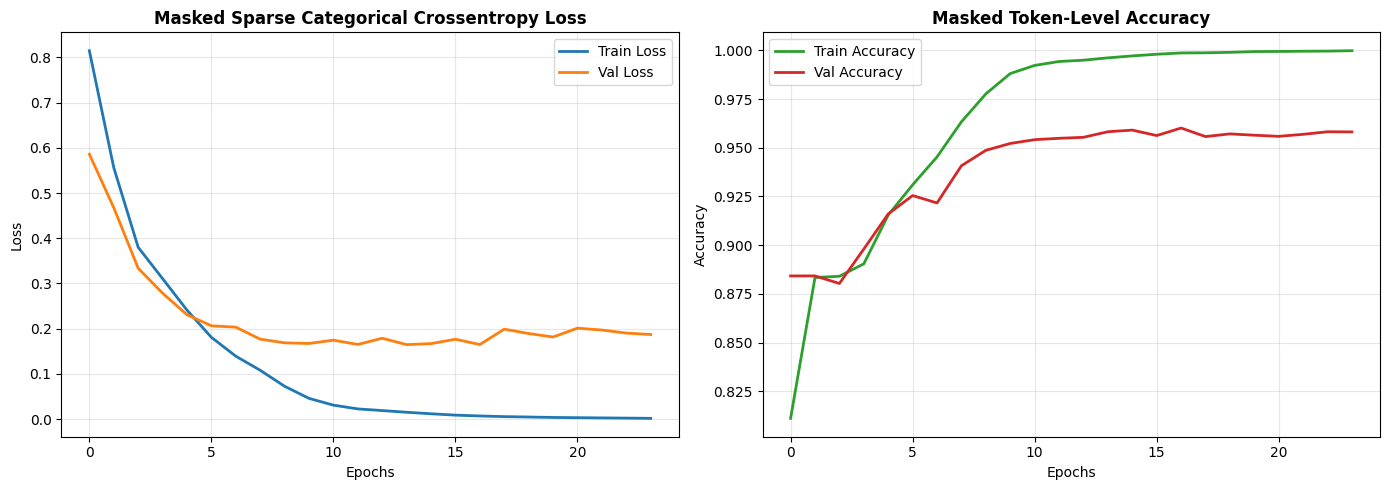

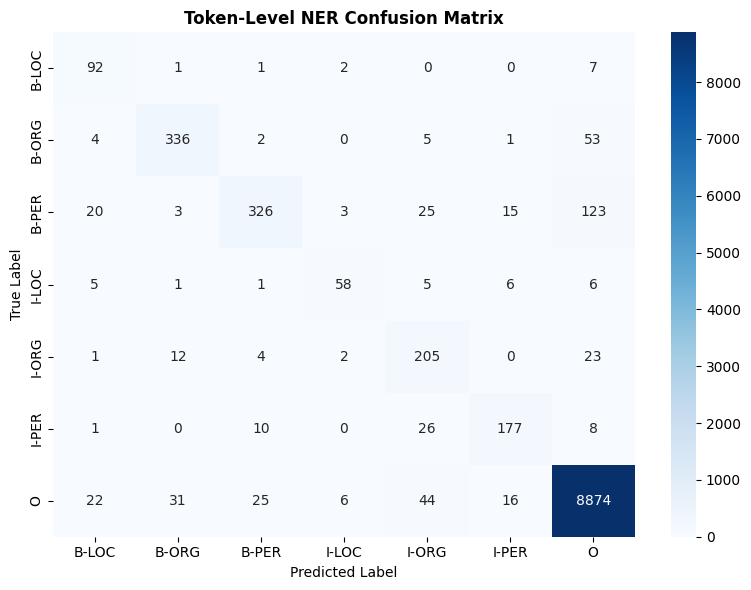

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2)
ax1.set_title('Masked Sparse Categorical Crossentropy Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(history.history['masked_accuracy'], label='Train Accuracy', color='#2ca02c', lw=2)
ax2.plot(history.history['val_masked_accuracy'], label='Val Accuracy', color='#d62728', lw=2)
ax2.set_title('Masked Token-Level Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
flat_true = [t for seq in true_seqs for t in seq]
flat_pred = [p for seq in pred_seqs for p in seq]
labels = sorted(list(set(flat_true + flat_pred)))

cm = confusion_matrix(flat_true, flat_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Token-Level NER Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 11. TFLite Quantization & Deployment Artifact Export

In [ ]:
# 1. Save Full Keras Model
model_keras_path = os.path.join(output_dir, "model.keras")
model.save(model_keras_path)
print(f"Saved full model to {model_keras_path}")

# 2. Convert to Quantized TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()
tflite_path = os.path.join(output_dir, "optimized_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"Saved quantized TFLite model to {tflite_path} ({len(tflite_model)/1024/1024:.2f} MB)")

# 3. Save Text Vectorizer
vect_data = {
    'config': vectorizer.get_config(),
    'vocabulary': vectorizer.get_vocabulary()
}
with open(os.path.join(output_dir, "vectorizer.pkl"), "wb") as f:
    pickle.dump(vect_data, f)

# 4. Save Mappings
joblib.dump(tag_to_idx, os.path.join(output_dir, "tag_to_idx.pkl"))
joblib.dump(pos_to_idx, os.path.join(output_dir, "pos_to_idx.pkl"))

# 5. Save Experiment Metadata JSON
exp_results = {
    "config": {
        "embed_dim": 150,
        "pos_embed_dim": int(best_hps.get('pos_embed_dim')),
        "w2v_window": 5,
        "w2v_min_count": 1,
        "w2v_epochs": 10,
        "w2v_sg": 1,
        "lstm_units": int(best_hps.get('lstm_units')),
        "dropout": float(best_hps.get('dropout')),
        "learning_rate": float(best_hps.get('learning_rate')),
        "trainable_embeddings": True,
        "num_lstm_layers": 2,
        "epochs": len(history.history['loss']),
        "batch_size": 128,
        "max_cap_len": max_len,
        "patience": 10
    },
    "metrics": {
        "val_loss": float(min(history.history['val_loss'])),
        "val_accuracy": float(max(history.history['val_masked_accuracy'])),
        "entity_f1": float(entity_f1),
        "entity_precision": float(entity_p),
        "entity_recall": float(entity_r)
    },
    "vocab_size": vocab_size,
    "num_pos_tags": len(pos_to_idx),
    "num_classes": len(tag_to_idx),
    "timestamp": datetime.now().isoformat()
}
with open(os.path.join(output_dir, "experiment_results.json"), "w") as f:
    json.dump(exp_results, f, indent=2)

print("\nAll deployment artifacts successfully saved to:", output_dir)
for fpath in os.listdir(output_dir):
    full_p = os.path.join(output_dir, fpath)
    print(f" - {fpath:<25} ({os.path.getsize(full_p)/1024:.1f} KB)")

Saved full model to C:\Users\GlaZ\Code_Repo\indogist\ml\models\ner_pos_final\model.keras


INFO:tensorflow:Assets written to: C:\Users\GlaZ\AppData\Local\Temp\tmp65z640lt\assets


INFO:tensorflow:Assets written to: C:\Users\GlaZ\AppData\Local\Temp\tmp65z640lt\assets


Saved artifact at 'C:\Users\GlaZ\AppData\Local\Temp\tmp65z640lt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, None), dtype=tf.float32, name='word_input'), TensorSpec(shape=(None, None), dtype=tf.float32, name='pos_input')]
Output Type:
  TensorSpec(shape=(None, None, 8), dtype=tf.float32, name=None)
Captures:
  1761865150544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865151504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865144592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865146128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865146896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865150352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865149968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865149584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761865152080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  176

Saved quantized TFLite model to C:\Users\GlaZ\Code_Repo\indogist\ml\models\ner_pos_final\optimized_model.tflite (1.85 MB)

All deployment artifacts successfully saved to: C:\Users\GlaZ\Code_Repo\indogist\ml\models\ner_pos_final
 - best_model_by_f1.keras    (21587.6 KB)
 - entity_report.txt         (0.4 KB)
 - experiment_results.json   (0.7 KB)
 - model.keras               (21587.6 KB)
 - optimized_model.tflite    (1893.0 KB)
 - pos_to_idx.pkl            (0.2 KB)
 - tag_to_idx.pkl            (0.1 KB)
 - vectorizer.pkl            (507.9 KB)
